<a href="https://colab.research.google.com/github/Gozuro/T48A-E03A/blob/feature%2F171877/Examen_Parcial_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
#4.1 Cargar y explorar datos
import pandas as pd

df = pd.read_csv('tickets_ficticios_TI.csv')
print(df.head())
print(df['categoria'].value_counts())
print(df['severidad'].value_counts())

  ticket_id categoria severidad  tiempo_resolucion_horas  \
0  TKT-1000  Hardware      Alta                     17.4   
1  TKT-1001       Red      Baja                     22.5   
2  TKT-1002  Hardware      Alta                     15.5   
3  TKT-1003  Software      Alta                     15.8   
4  TKT-1004       Red      Baja                     34.9   

                                         descripcion  
0  Servidor físico sin encender tras actualizació...  
1             Latencia elevada en enlace secundario.  
2  Servidor físico sin encender tras actualizació...  
3  Error crítico en base de datos: servicio no ar...  
4             Latencia elevada en enlace secundario.  
categoria
Red         82
Hardware    61
Software    57
Name: count, dtype: int64
severidad
Alta     73
Baja     66
Media    61
Name: count, dtype: int64


In [89]:
# 4.2 Preprocesamiento
# Convertir severidad y categoria a etiquetas numéricas cuando sea necesario.
# Escalar tiempo_resolucion_horas.
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Mapear severidad a números
le_severidad = LabelEncoder()
df['severidad_encoded'] = le_severidad.fit_transform(df['severidad'])

# Etiquetas de salida (clasificación por categoria)
le_categoria = LabelEncoder()
df['categoria_encoded'] = le_categoria.fit_transform(df['categoria'])

# Preparar características para modelos
X = df[['severidad_encoded', 'tiempo_resolucion_horas']].copy()
y = df['categoria_encoded'].copy()

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir datos para clasificación
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Mapa de severidad: {dict(enumerate(le_severidad.classes_))}")
print(f"Mapa de categoría: {dict(enumerate(le_categoria.classes_))}")
print(f"Datos preprocesados: {X_scaled.shape}")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Mapa de severidad: {0: 'Alta', 1: 'Baja', 2: 'Media'}
Mapa de categoría: {0: 'Hardware', 1: 'Red', 2: 'Software'}
Datos preprocesados: (200, 2)
Conjunto de entrenamiento: 140 muestras
Conjunto de prueba: 60 muestras


In [96]:
# Clasificación con K-NN
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

print('Exactitud K-NN:', knn.score(X_test, y_test))

Exactitud K-NN: 0.36666666666666664


In [97]:
#4.4 Clasificación con Perceptrón

from sklearn.linear_model import Perceptron


# Instantiate the Perceptron model
perc = Perceptron(random_state=42)
# Fit the model to the training data
perc.fit(X_train, y_train)

print('Exactitud Perceptrón:', perc.score(X_test, y_test))

Exactitud Perceptrón: 0.43333333333333335


In [99]:
#4.5 Clasificación con MLP
from sklearn.neural_network import MLPClassifier


print('Exactitud MLP:', mlp.score(X_test, y_test))

Exactitud MLP: 0.38333333333333336


In [101]:
#4.6 Clustering con K-Means
from sklearn.cluster import KMeans

print('Tamaño de clusters:', pd.Series(cluster_labels).value_counts().to_dict())
print('Centroides:', kmeans.cluster_centers_)

Tamaño de clusters: {2: 74, 0: 68, 1: 58}
Centroides: [[ 1.29848929  0.07479243]
 [-0.71049414 -0.77846953]
 [-0.37880457  0.8291949 ]]


In [94]:
#4.7 SOM
!pip install minisom
from minisom import MiniSom

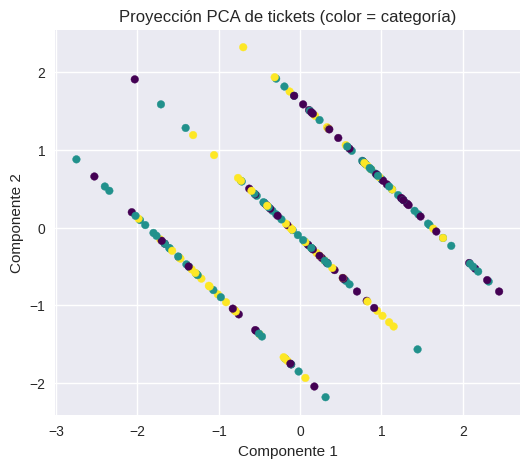

In [102]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', s=30)
plt.title('Proyección PCA de tickets (color = categoría)')
plt.xlabel('Componente 1'); plt.ylabel('Componente 2')
plt.show()

In [104]:
from sklearn.metrics import confusion_matrix, classification_report


print(confusion_matrix(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp, target_names=le_categoria.classes_))

[[ 9  2  7]
 [ 5 16  4]
 [ 5  2 10]]
              precision    recall  f1-score   support

    Hardware       0.47      0.50      0.49        18
         Red       0.80      0.64      0.71        25
    Software       0.48      0.59      0.53        17

    accuracy                           0.58        60
   macro avg       0.58      0.58      0.57        60
weighted avg       0.61      0.58      0.59        60



In [105]:
from sklearn.metrics import silhouette_score
print('Silhouette:', silhouette_score(X, labels))

Silhouette: 0.13847404264990643
